In [ ]:
import pandas as pd

file_path = '/content/Financial Sample.xlsx'
df = pd.read_excel(file_path)

display(df.head())

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,NaN,1618.5,3,20,32370.0,0.0,32370.0,16185.0,16185.0,2014-01-01,1,January,2014
1,Government,Germany,Carretera,NaN,1321.0,3,20,26420.0,0.0,26420.0,13210.0,13210.0,2014-01-01,1,January,2014
2,Midmarket,France,Carretera,NaN,2178.0,3,15,32670.0,0.0,32670.0,21780.0,10890.0,2014-06-01,6,June,2014
3,Midmarket,Germany,Carretera,NaN,888.0,3,15,13320.0,0.0,13320.0,8880.0,4440.0,2014-06-01,6,June,2014
4,Midmarket,Mexico,Carretera,NaN,2470.0,3,15,37050.0,0.0,37050.0,24700.0,12350.0,2014-06-01,6,June,2014


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Segment              700 non-null    object        
 1   Country              700 non-null    object        
 2   Product              700 non-null    object        
 3   Discount Band        647 non-null    object        
 4   Units Sold           700 non-null    float64       
 5   Manufacturing Price  700 non-null    int64         
 6   Sale Price           700 non-null    int64         
 7   Gross Sales          700 non-null    float64       
 8   Discounts            700 non-null    float64       
 9    Sales               700 non-null    float64       
 10  COGS                 700 non-null    float64       
 11  Profit               700 non-null    float64       
 12  Date                 700 non-null    datetime64[ns]
 13  Month Number         700 non-null  

In [ ]:
display(df.describe())

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year
count,700.000000,700.000000,700.000000,7.000000e+02,700.000000,7.000000e+02,700.000000,700.000000,700,700.000000,700.000000
mean,1608.294286,96.477143,118.428571,1.827594e+05,13150.354629,1.696091e+05,145475.211429,24133.860371,2014-04-28 21:36:00,7.900000,2013.750000
min,200.000000,3.000000,7.000000,1.799000e+03,0.000000,1.655080e+03,918.000000,-40617.500000,2013-09-01 00:00:00,1.000000,2013.000000
25%,905.000000,5.000000,12.000000,1.739175e+04,800.320000,1.592800e+04,7490.000000,2805.960000,2013-12-24 06:00:00,5.750000,2013.750000
50%,1542.500000,10.000000,20.000000,3.798000e+04,2585.250000,3.554020e+04,22506.250000,9242.200000,2014-05-16 12:00:00,9.000000,2014.000000
75%,2229.125000,250.000000,300.000000,2.790250e+05,15956.343750,2.610775e+05,245607.500000,22662.000000,2014-09-08 12:00:00,10.250000,2014.000000
max,4492.500000,260.000000,350.000000,1.207500e+06,149677.500000,1.159200e+06,950625.000000,262200.000000,2014-12-01 00:00:00,12.000000,2014.000000
std,867.427859,108.602612,136.775515,2.542623e+05,22962.928775,2.367263e+05,203865.506118,42760.626563,NaN,3.377321,0.433322


Ahora, revisemos los valores únicos de algunas de las columnas categóricas más relevantes para entender la variedad de datos en estas categorías.

In [ ]:
print('Unique values in Segment:', df['Segment'].unique())
print('Unique values in Country:', df['Country'].unique())
print('Unique values in Product:', df['Product'].unique())
print('Unique values in Discount Band:', df['Discount Band'].unique())

Unique values in Segment: ['Government' 'Midmarket' 'Channel Partners' 'Enterprise' 'Small Business']
Unique values in Country: ['Canada' 'Germany' 'France' 'Mexico' 'United States of America']
Unique values in Product: ['Carretera' 'Montana' 'Paseo' 'Velo' 'VTT' 'Amarilla']
Unique values in Discount Band: [nan 'Low' 'Medium' 'High']


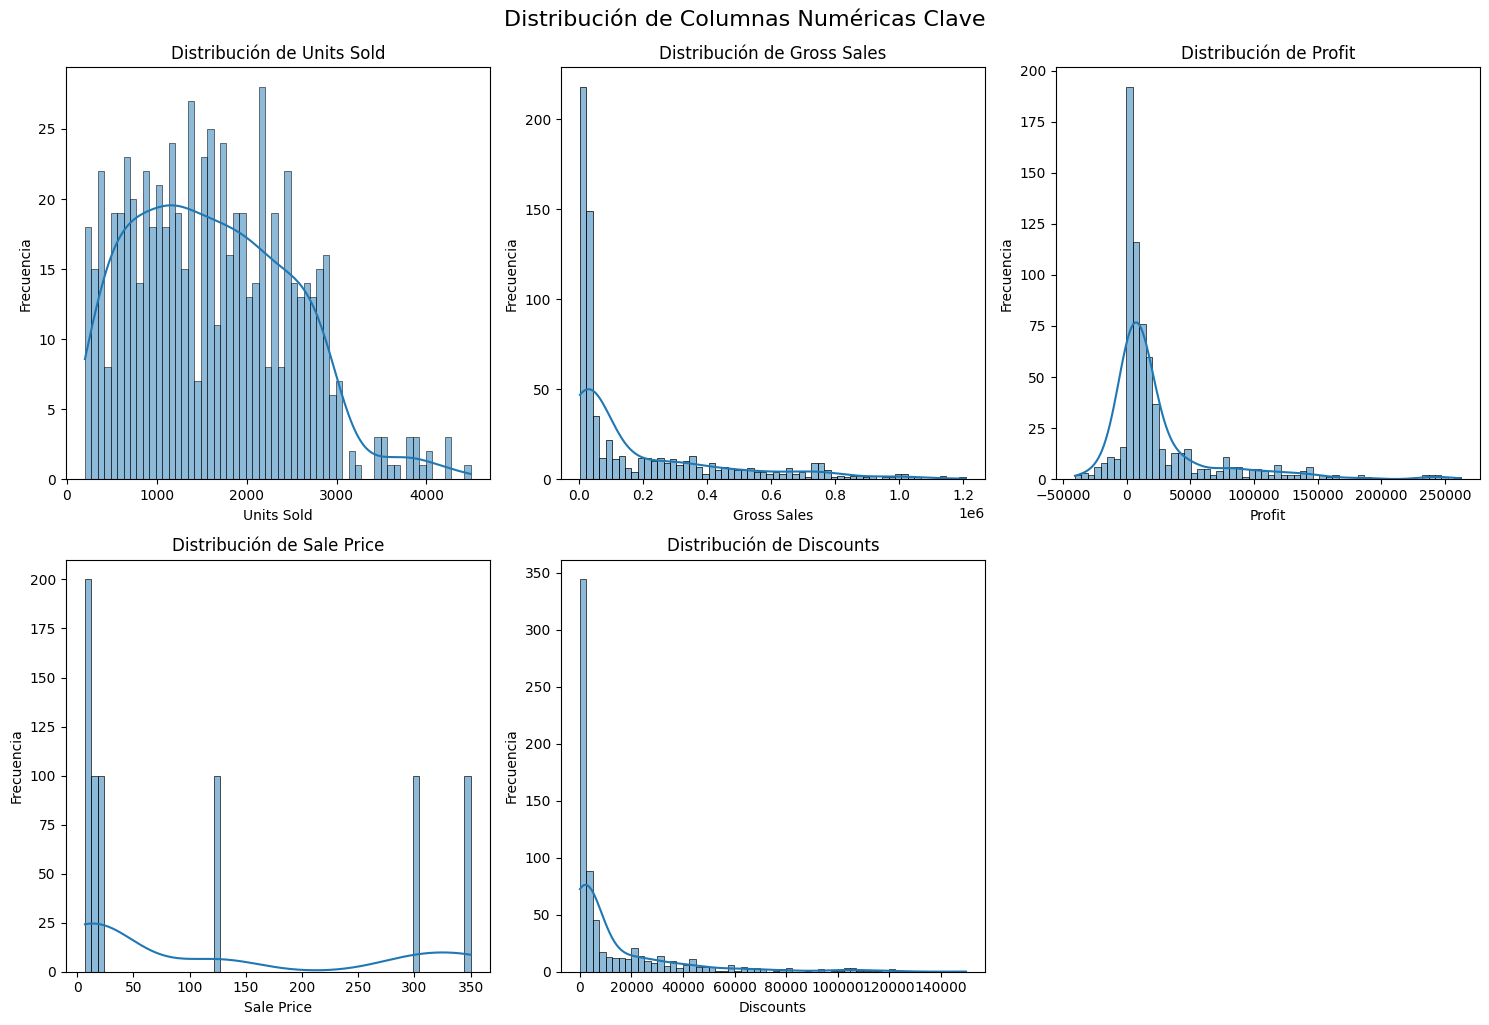

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de columnas numéricas para visualizar
numerical_cols = ['Units Sold', 'Gross Sales', 'Profit', 'Sale Price','Discounts']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Crear una cuadrícula de 2x2 subplots
    # Eliminamos el parámetro 'hue' que causaba el error y el 'palette' ya que no se necesita sin 'hue'
    sns.histplot(df[col], kde=True, bins=60) # 'kde=True' para la estimación de la densidad del kernel
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
plt.suptitle('Distribución de Columnas Numéricas Clave', y=1.02, fontsize=16) # Título general para el conjunto de gráficos
plt.show()

## Manejo de valores nulos

Porcentaje de Valores Nulos por Columna:
Segment                0.000000
Country                0.000000
Product                0.000000
Discount Band          7.571429
Units Sold             0.000000
Manufacturing Price    0.000000
Sale Price             0.000000
Gross Sales            0.000000
Discounts              0.000000
 Sales                 0.000000
COGS                   0.000000
Profit                 0.000000
Date                   0.000000
Month Number           0.000000
Month Name             0.000000
Year                   0.000000
dtype: float64


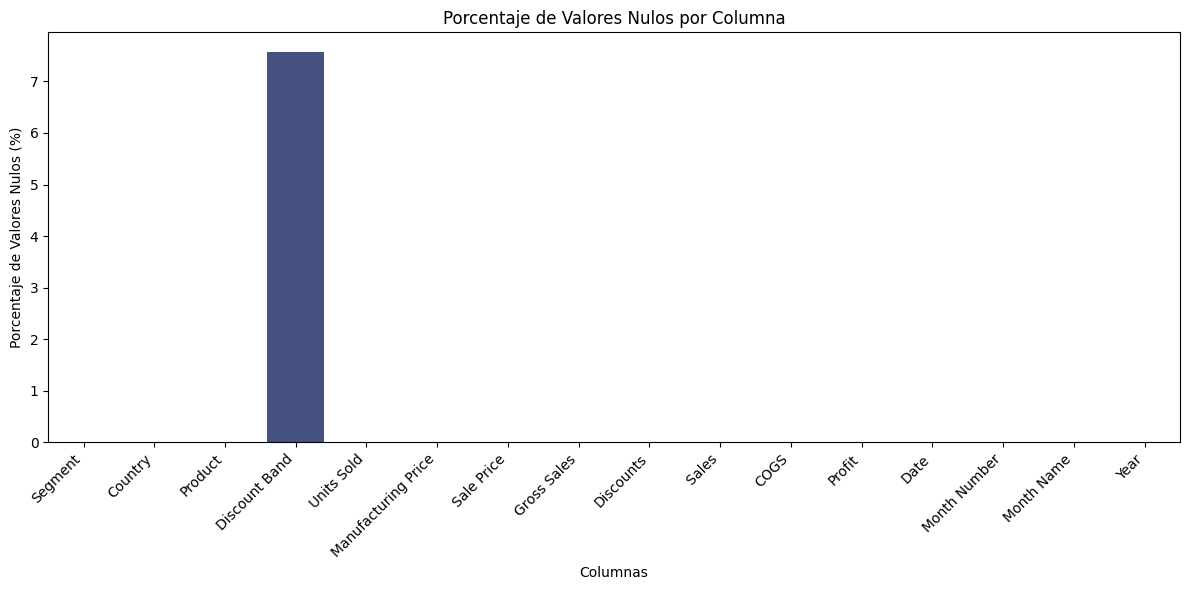

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage of null values for each column
null_percentages = (df.isnull().sum() / len(df)) * 100

# Filter out columns with 0% nulls for display if desired, or keep all
# For this request, we keep all to show 0% for non-null columns

# Display the null percentages
print('Porcentaje de Valores Nulos por Columna:')
print(null_percentages)

# Create a bar plot for null percentages
if not null_percentages.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=null_percentages.index, y=null_percentages.values, palette='viridis', hue=null_percentages.index, legend=False)
    plt.title('Porcentaje de Valores Nulos por Columna')
    plt.xlabel('Columnas')
    plt.ylabel('Porcentaje de Valores Nulos (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
elif null_percentages.empty:
    print('No hay columnas en el DataFrame.')

##Imputar - variables categoricas

### Imputar con nuevo valor

In [ ]:
df['Discount Band'].fillna('No Discount', inplace=True)

/tmp/ipykernel_1757/3143315722.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Discount Band'].fillna('No Discount', inplace=True)


In [ ]:
null_count_discount_band = df['Discount Band'].isnull().sum()
total_rows = len(df)
percentage_null_discount_band = (null_count_discount_band / total_rows) * 100

print(f"Number of null values in 'Discount Band': {null_count_discount_band}")
print(f"Percentage of null values in 'Discount Band': {percentage_null_discount_band:.2f}%")

Number of null values in 'Discount Band': 0
Percentage of null values in 'Discount Band': 0.00%


In [ ]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,No Discount,1618.5,3,20,32370.0,0.0,32370.0,16185.0,16185.0,2014-01-01,1,January,2014
1,Government,Germany,Carretera,No Discount,1321.0,3,20,26420.0,0.0,26420.0,13210.0,13210.0,2014-01-01,1,January,2014
2,Midmarket,France,Carretera,No Discount,2178.0,3,15,32670.0,0.0,32670.0,21780.0,10890.0,2014-06-01,6,June,2014
3,Midmarket,Germany,Carretera,No Discount,888.0,3,15,13320.0,0.0,13320.0,8880.0,4440.0,2014-06-01,6,June,2014
4,Midmarket,Mexico,Carretera,No Discount,2470.0,3,15,37050.0,0.0,37050.0,24700.0,12350.0,2014-06-01,6,June,2014


## Imputar con moda

In [ ]:
# Calcular la moda de la columna 'Discount Band'
# [0] se usa porque .mode() puede devolver múltiples modas si hay un empate
discount_band_mode = df['Discount Band'].mode()[0]

# Imputar los valores nulos con la moda
df['Discount Band'].fillna(discount_band_mode, inplace=True)

##Imputar variables numericas

In [ ]:
df["Sale"].fillna(df["Sale"].mean(), inplace=True) #imputar con media (sensible a valores extremos - outliers)
df["Sale"].fillna(df["Sale"].median(), inplace=True) #Imputar con mediana (mejor para manejar outliers)
df = df.dropna(subset=["Sale"]) # Eliminar filas con nulos (cuando el % de nulos no es representativo)

### Exploración de Variables Categóricas (antes de aplicar técnicas de multocolinealidas)

Vamos a visualizar la distribución de algunas de las columnas categóricas más importantes para ver la frecuencia de cada categoría. Utilizaremos gráficos de conteo para esto.

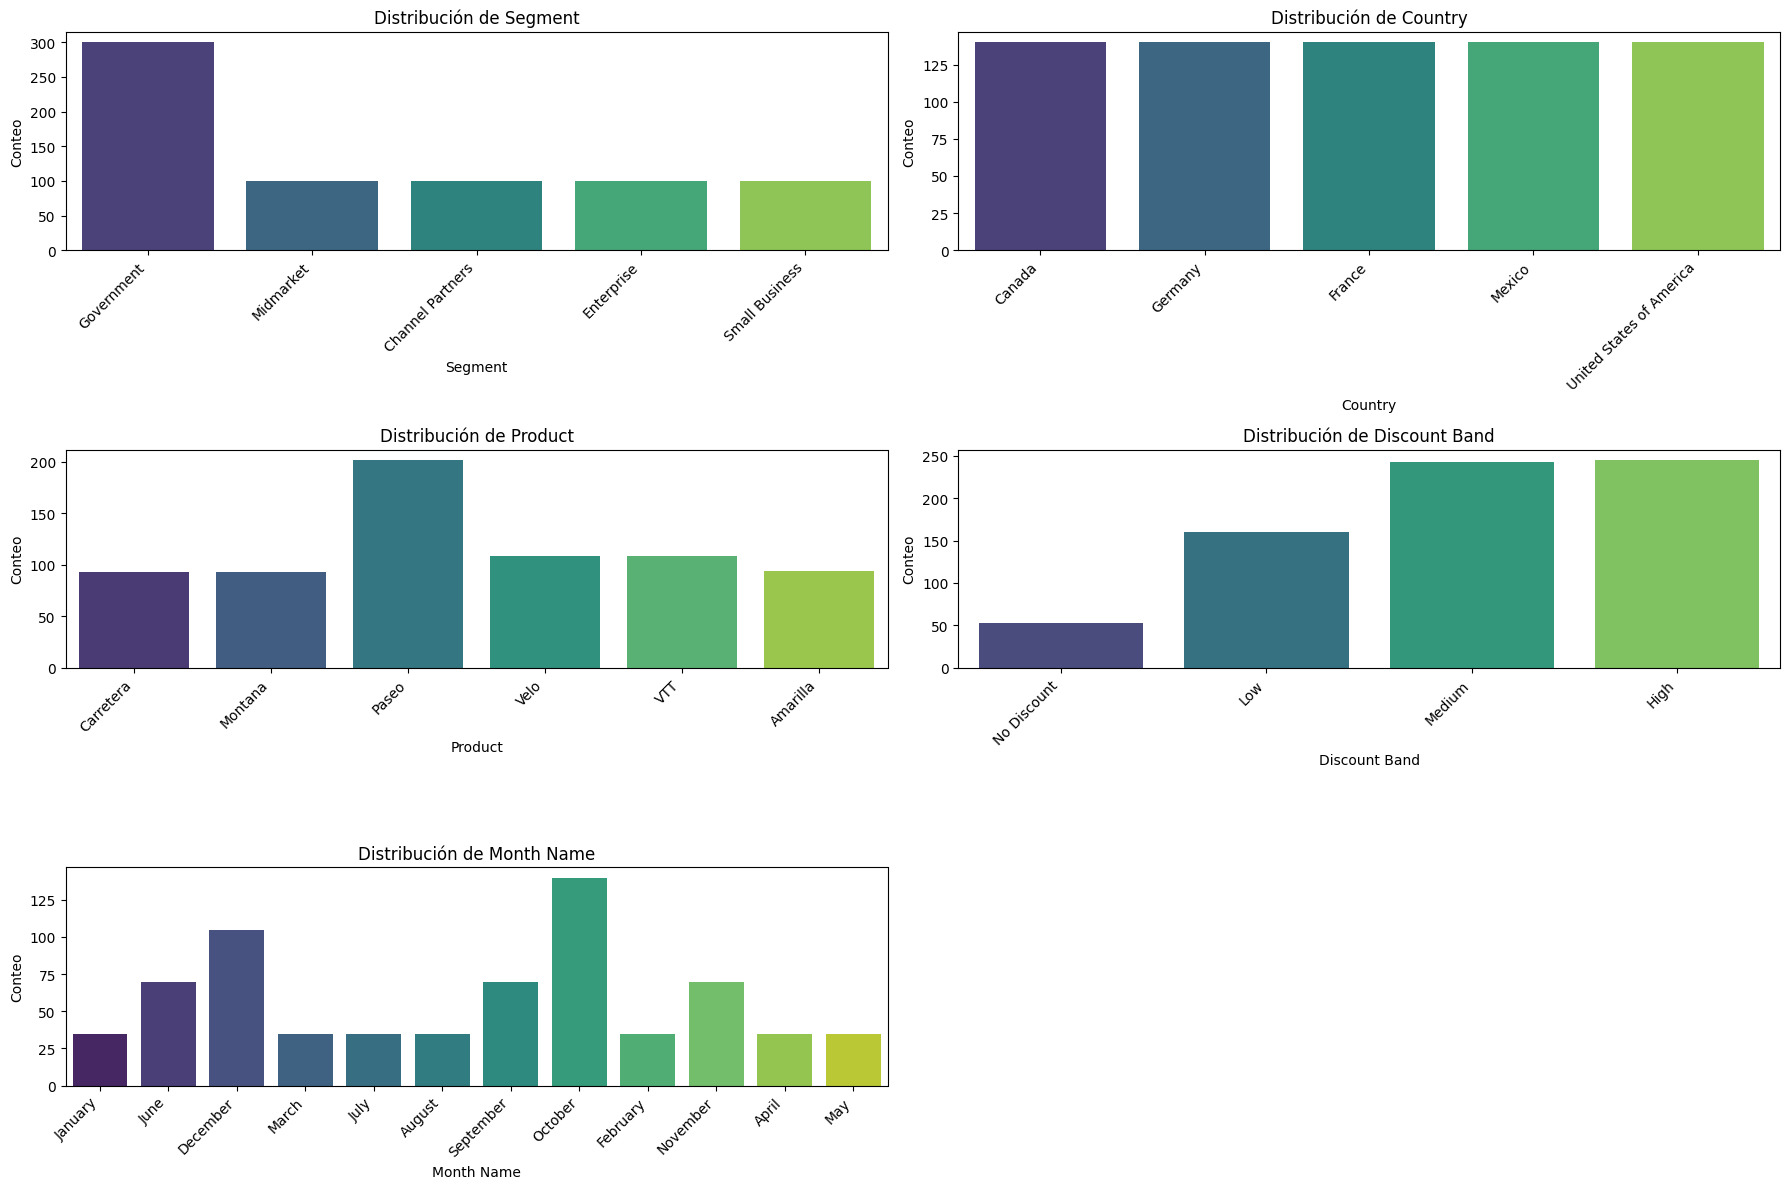

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['Segment', 'Country', 'Product', 'Discount Band', 'Month Name']

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 2, i + 1) # Ajusta el tamaño de la cuadrícula según el número de columnas
    sns.countplot(data=df, x=col, palette='viridis', hue=col, legend=False)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Conteo')
    plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

### Relación de 'Product' y 'Discount Band' con 'Profit' y 'Sales'

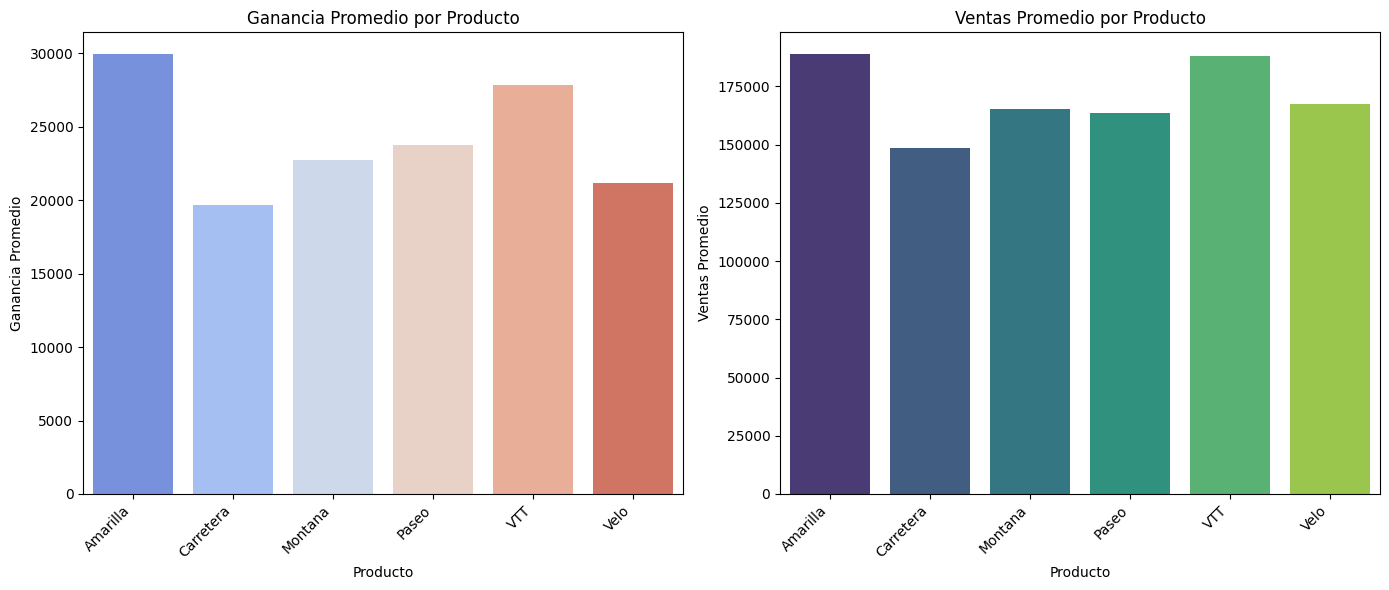

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por 'Product' y calcular el promedio de 'Profit' y 'Sales'
product_profit_sales = df.groupby('Product')[['Profit', ' Sales']].mean().reset_index()

plt.figure(figsize=(14, 6))

# Gráfico de barras para 'Profit' por 'Product'
plt.subplot(1, 2, 1)
sns.barplot(x='Product', y='Profit', data=product_profit_sales, palette='coolwarm', hue='Product', legend=False)
plt.title('Ganancia Promedio por Producto')
plt.xlabel('Producto')
plt.ylabel('Ganancia Promedio')
plt.xticks(rotation=45, ha='right')

# Gráfico de barras para 'Sales' por 'Product'
plt.subplot(1, 2, 2)
sns.barplot(x='Product', y=' Sales', data=product_profit_sales, palette='viridis', hue='Product', legend=False)
plt.title('Ventas Promedio por Producto')
plt.xlabel('Producto')
plt.ylabel('Ventas Promedio')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

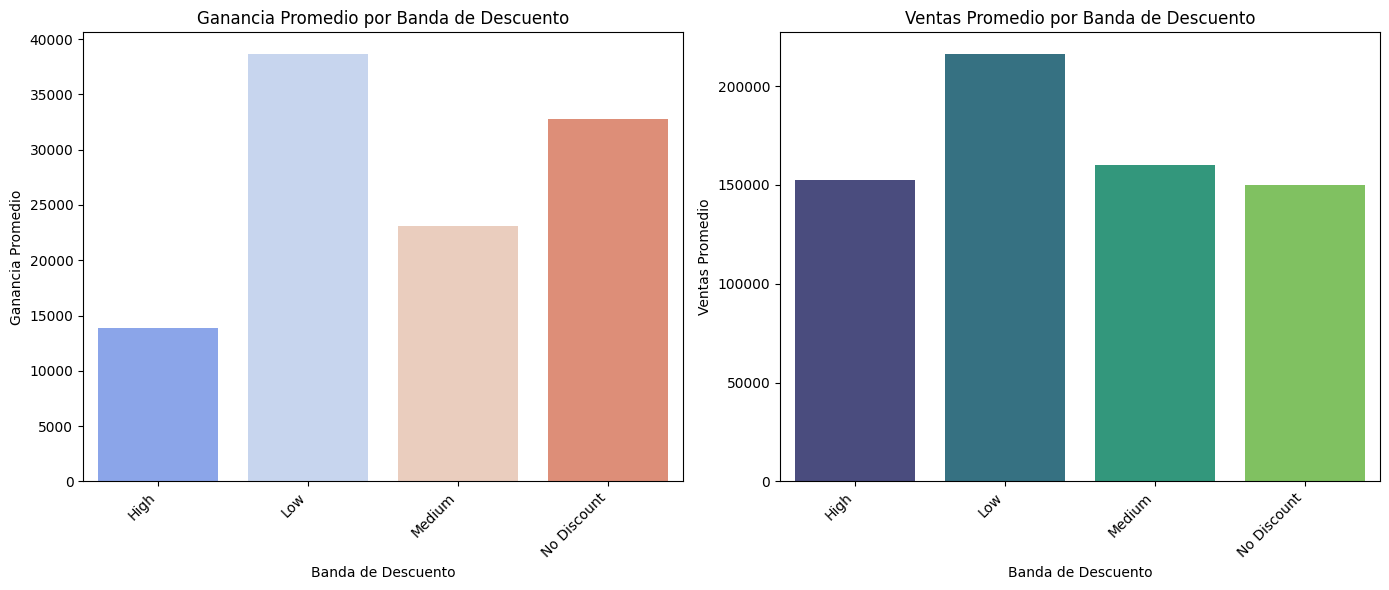

In [ ]:
#este grafico está sospechoso, deberia estar relacioando con discounts
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por 'Discount Band' y calcular el promedio de 'Profit' y 'Sales'
discount_band_profit_sales = df.groupby('Discount Band')[['Profit', ' Sales']].mean().reset_index()

plt.figure(figsize=(14, 6))

# Gráfico de barras para 'Profit' por 'Discount Band'
plt.subplot(1, 2, 1)
sns.barplot(x='Discount Band', y='Profit', data=discount_band_profit_sales, palette='coolwarm', hue='Discount Band', legend=False)
plt.title('Ganancia Promedio por Banda de Descuento')
plt.xlabel('Banda de Descuento')
plt.ylabel('Ganancia Promedio')
plt.xticks(rotation=45, ha='right')

# Gráfico de barras para 'Sales' por 'Discount Band'
plt.subplot(1, 2, 2)
sns.barplot(x='Discount Band', y=' Sales', data=discount_band_profit_sales, palette='viridis', hue='Discount Band', legend=False)
plt.title('Ventas Promedio por Banda de Descuento')
plt.xlabel('Banda de Descuento')
plt.ylabel('Ventas Promedio')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Exploración de Relaciones entre Variables Categóricas y Numéricas

Vamos a analizar cómo las variables categóricas como 'Segmento' y 'País' influyen en las métricas numéricas clave como 'Profit' (Ganancia) y 'Sales' (Ventas). Utilizaremos gráficos de barras para visualizar los promedios.

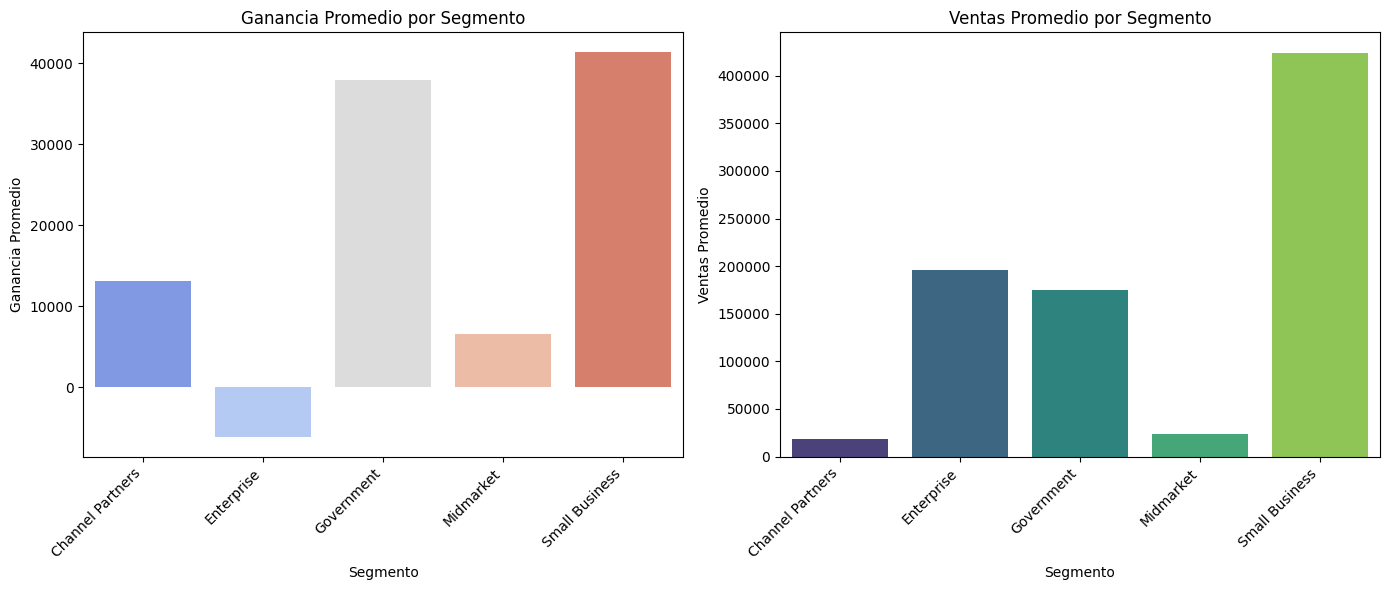

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por 'Segment' y calcular el promedio de 'Profit' y 'Sales'
segment_profit_sales = df.groupby('Segment')[['Profit', ' Sales']].mean().reset_index()

plt.figure(figsize=(14, 6))

# Gráfico de barras para 'Profit' por 'Segment'
plt.subplot(1, 2, 1)
sns.barplot(x='Segment', y='Profit', data=segment_profit_sales, palette='coolwarm', hue='Segment', legend=False)
plt.title('Ganancia Promedio por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Ganancia Promedio')
plt.xticks(rotation=45, ha='right')

# Gráfico de barras para 'Sales' por 'Segment'
plt.subplot(1, 2, 2)
sns.barplot(x='Segment', y=' Sales', data=segment_profit_sales, palette='viridis', hue='Segment', legend=False)
plt.title('Ventas Promedio por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Ventas Promedio')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


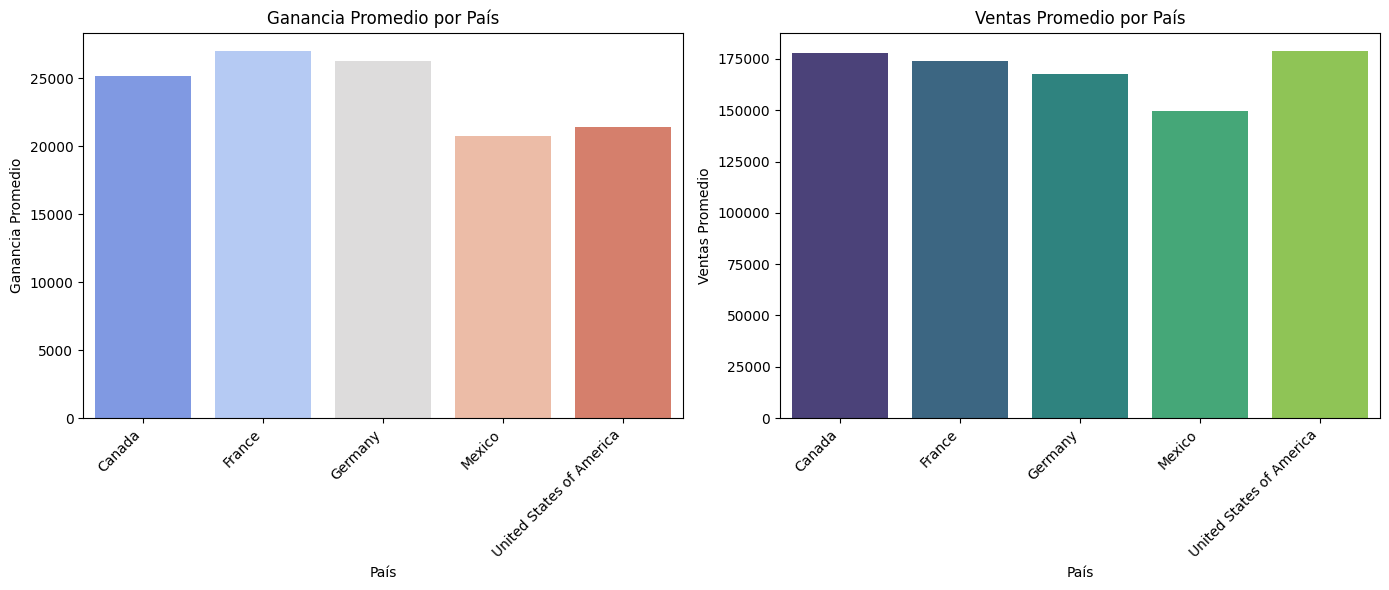

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por 'Country' y calcular el promedio de 'Profit' y 'Sales'
country_profit_sales = df.groupby('Country')[['Profit', ' Sales']].mean().reset_index()

plt.figure(figsize=(14, 6))

# Gráfico de barras para 'Profit' por 'Country'
plt.subplot(1, 2, 1)
sns.barplot(x='Country', y='Profit', data=country_profit_sales, palette='coolwarm', hue='Country', legend=False)
plt.title('Ganancia Promedio por País')
plt.xlabel('País')
plt.ylabel('Ganancia Promedio')
plt.xticks(rotation=45, ha='right')

# Gráfico de barras para 'Sales' por 'Country'
plt.subplot(1, 2, 2)
sns.barplot(x='Country', y=' Sales', data=country_profit_sales, palette='viridis', hue='Country', legend=False)
plt.title('Ventas Promedio por País')
plt.xlabel('País')
plt.ylabel('Ventas Promedio')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Detección de Outliers en Variables Numéricas

Vamos a utilizar box plots (gráficos de caja) para visualizar la distribución de las variables numéricas y detectar posibles outliers.

/tmp/ipykernel_1757/377055307.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis')
/tmp/ipykernel_1757/377055307.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis')
/tmp/ipykernel_1757/377055307.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis')
/tmp/ipykernel_1757/377055307.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sa

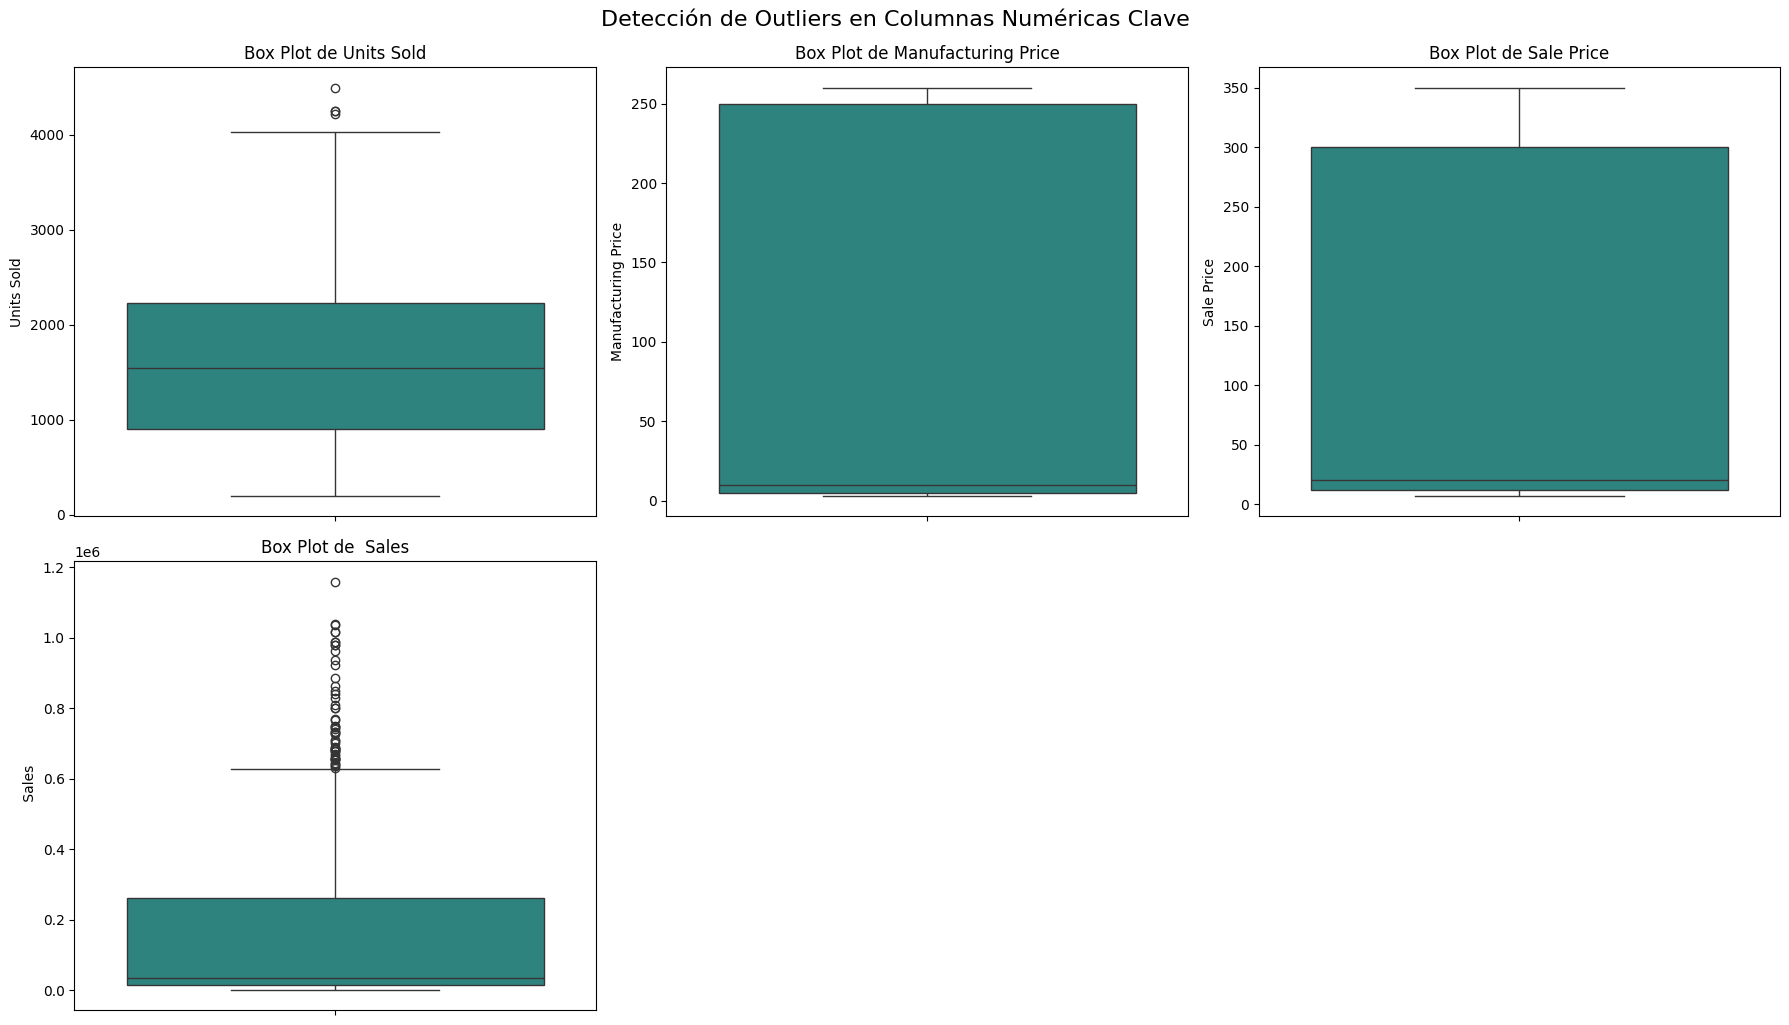

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de columnas numéricas que se desean analizar para outliers
# Excluyo 'Month Number' y 'Year' ya que son categóricas por naturaleza para este análisis
numerical_cols_for_outliers = ['Units Sold', 'Manufacturing Price', 'Sale Price', ' Sales']

plt.figure(figsize=(18, 10))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(2, 3, i + 1) # Ajusta la cuadrícula según el número de columnas
    sns.boxplot(y=df[col], palette='viridis')
    plt.title(f'Box Plot de {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.suptitle('Detección de Outliers en Columnas Numéricas Clave', y=1.02, fontsize=16)
plt.show()

### Manejo de Outliers en ' Sales'

Vamos a aplicar la técnica de capping (limitación) para los outliers en la columna ' Sales' utilizando el método del rango intercuartílico (IQR). Esto reemplazará los valores extremos por un umbral calculado, reduciendo su impacto en el análisis.

Se han limitado los valores de ' Sales' por encima de: 628801.75


/tmp/ipykernel_1757/2468716628.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[' Sales'], palette='viridis')


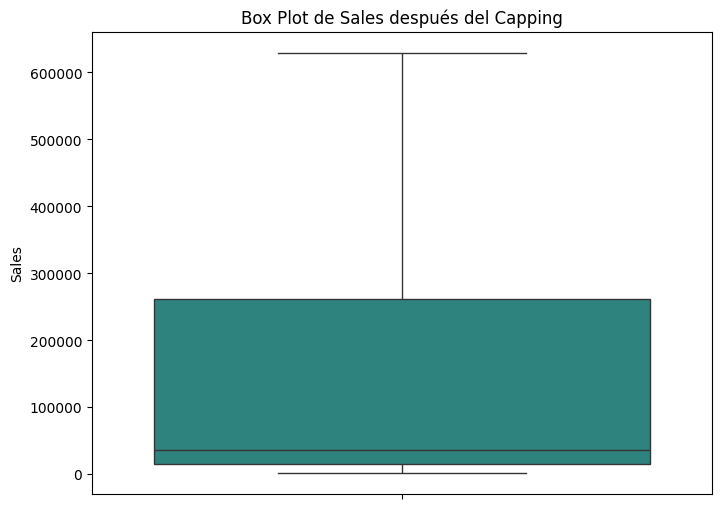

In [ ]:
import numpy as np

# Calcular el IQR para ' Sales'
Q1 = df[' Sales'].quantile(0.25)
Q3 = df[' Sales'].quantile(0.75)
IQR = Q3 - Q1

# Definir los límites para el capping de outliers. Nos enfocaremos en los superiores.
upper_bound = Q3 + 1.5 * IQR

# Aplicar capping a los valores superiores de ' Sales'
df[' Sales'] = np.where(df[' Sales'] > upper_bound, upper_bound, df[' Sales'])

print(f"Se han limitado los valores de ' Sales' por encima de: {upper_bound:.2f}")

# Opcional: Re-visualizar el box plot de ' Sales' para ver el efecto
plt.figure(figsize=(8, 6))
sns.boxplot(y=df[' Sales'], palette='viridis')
plt.title('Box Plot de Sales después del Capping')
plt.ylabel('Sales')
plt.show()

### Análisis de Tendencias Temporales

Ahora, exploremos las tendencias de ventas y ganancias a lo largo del tiempo, agrupando por mes y año para ver patrones temporales.

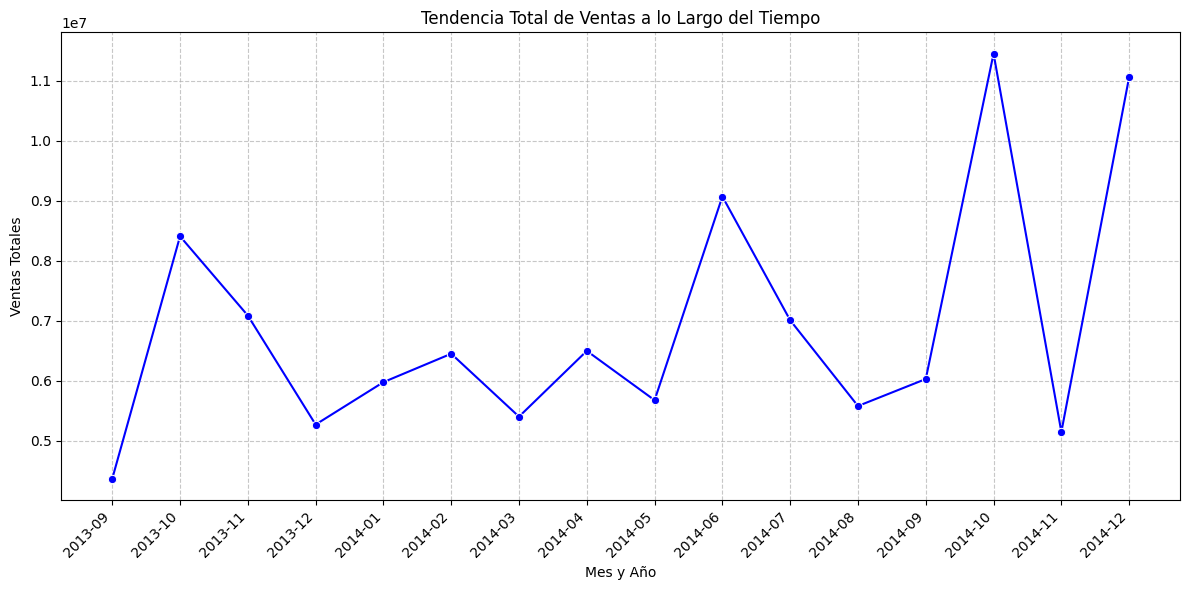

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarse de que la columna 'Date' sea de tipo datetime
df['Date'] = pd.to_datetime(df['Date'])

# Agrupar por mes y año para analizar tendencias
df['YearMonth'] = df['Date'].dt.to_period('M')
trend_data = df.groupby('YearMonth')[[' Sales']].sum().reset_index()
trend_data['YearMonth'] = trend_data['YearMonth'].astype(str) # Convertir a string para graficar

plt.figure(figsize=(12, 6))
sns.lineplot(x='YearMonth', y=' Sales', data=trend_data, marker='o', color='blue')
plt.title('Tendencia Total de Ventas a lo Largo del Tiempo')
plt.xlabel('Mes y Año')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Manejo de multicolinealidad

##Matriz de correlacion

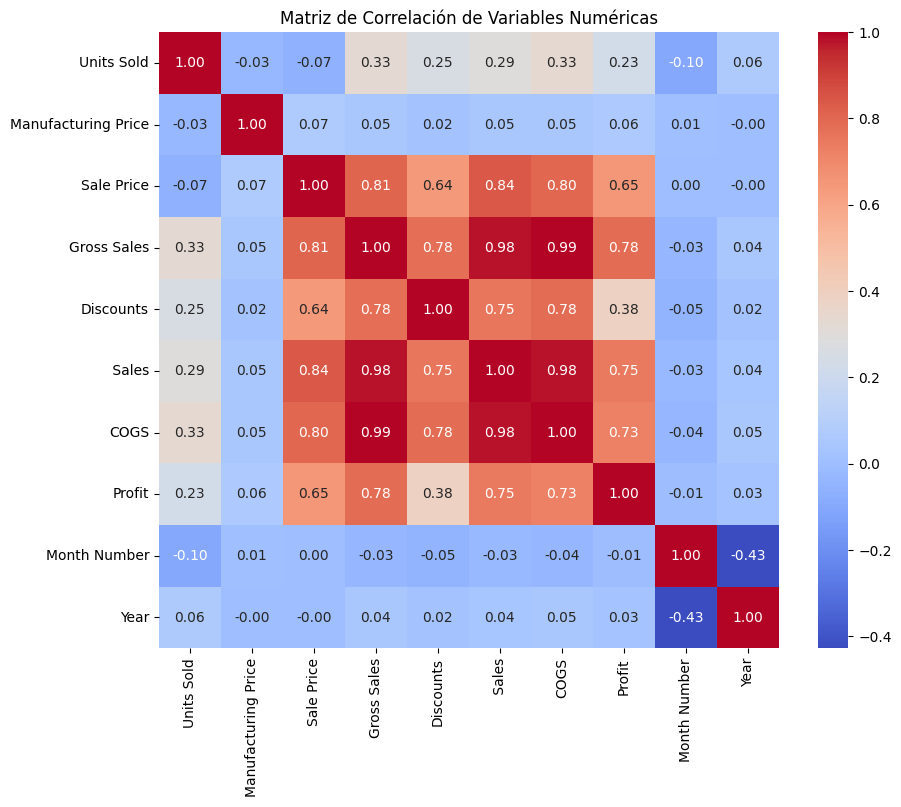

In [ ]:
# Seleccionar solo las columnas numéricas para calcular la correlación
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

In [ ]:
#creacion de una nueva variable que representa las dos variables,
# eliminando multicolinealidad
df["discount_rate"] = df["Discounts"] / df["Gross Sales"]  #esto es ingniería de caracteristicas


In [ ]:
df = df.drop(columns=["Gross Sales","Discounts"])

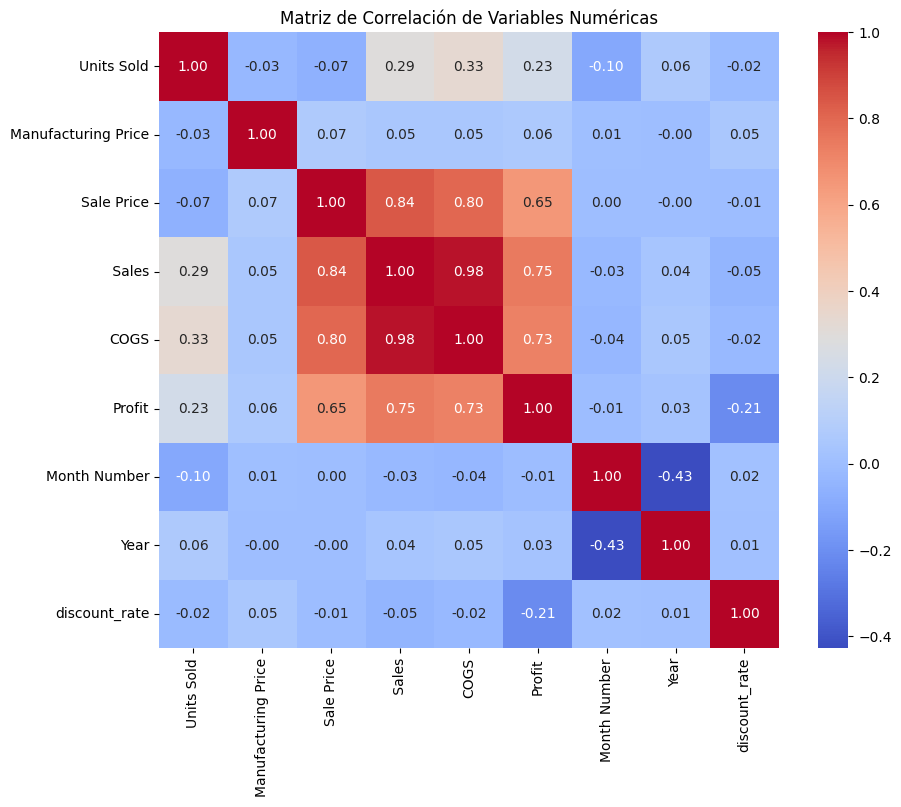

In [ ]:
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

##aplicación de VIF

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.select_dtypes(include=["float64", "int64"])

vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

              variable        VIF
0           Units Sold   7.890437
1  Manufacturing Price   1.809372
2           Sale Price   9.838491
3                Sales  57.110607
4                 COGS  41.438690
5               Profit   3.274967
6         Month Number   6.566859
7                 Year  17.543036
8        discount_rate   3.936082


In [ ]:
#Para efectos de un modelo de prediccion se puede eliminar estas variables
# dejarlas seria agregar redundancia al modelo
df = df.drop(columns=[" Sales"])

In [ ]:
df = df.drop(columns=["Year"])

In [ ]:
X = df.select_dtypes(include=["float64", "int64"])

vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

              variable       VIF
0           Units Sold  4.584357
1  Manufacturing Price  1.744832
2           Sale Price  6.316839
3                 COGS  6.878872
4               Profit  3.182259
5         Month Number  4.147797
6        discount_rate  3.402685


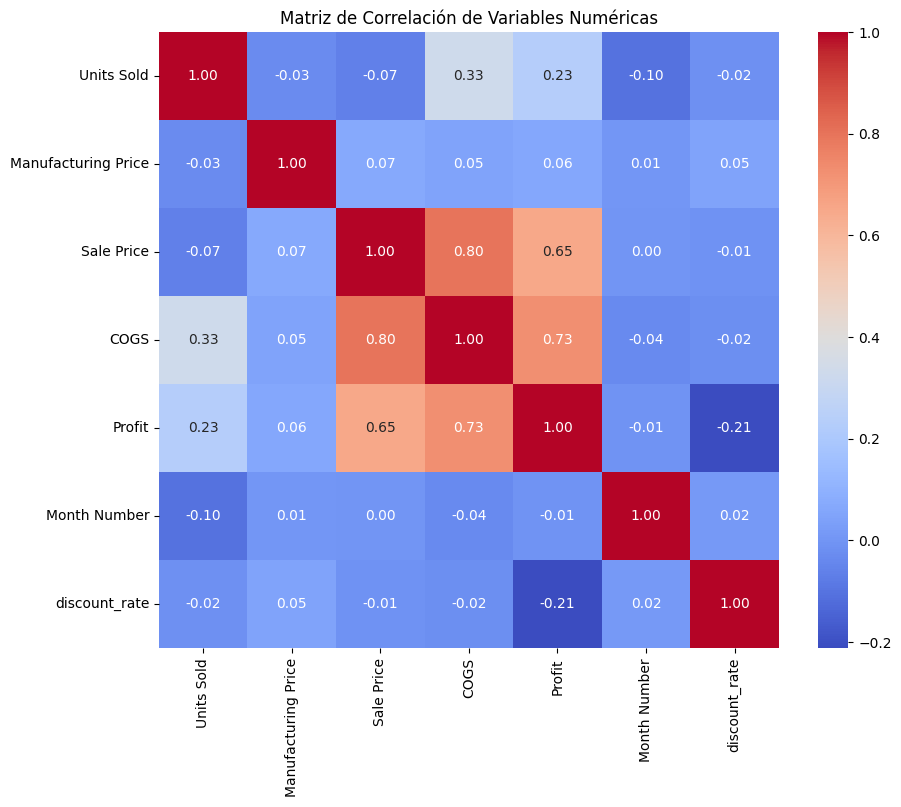

In [ ]:
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

### Codificación de Variables Categóricas

Vamos a preparar las variables categóricas para el análisis o modelado. Utilizaremos One-Hot Encoding para las variables 'Segment', 'Country', 'Product' y 'Discount Band', ya que no tienen un orden inherente. Para 'Month Name' podemos usar Label Encoding si queremos mantener un orden, o One-Hot Encoding si no se considera una relación ordinal.

In [ ]:
import pandas as pd

# Realizar One-Hot Encoding para 'Segment', 'Country', 'Product', 'Discount Band'
df_encoded = pd.get_dummies(df, columns=['Segment', 'Country', 'Product', 'Discount Band'], drop_first=True)

# Convertir todas las columnas booleanas a enteros (1 y 0)
for col in df_encoded.select_dtypes(include='bool').columns:
    df_encoded[col] = df_encoded[col].astype(int)

# Eliminar la columna original 'Month Name' si 'Month Number' ya está presente y cumple la función
df_encoded = df_encoded.drop(columns=['Month Name'])

print('DataFrame con variables categóricas codificadas (True/False convertidas a 1/0):')
display(df_encoded.head())

DataFrame con variables categóricas codificadas (True/False convertidas a 1/0):


,Units Sold,Manufacturing Price,Sale Price,COGS,Profit,Date,Month Number,discount_rate,Segment_Enterprise,Segment_Government,...,Country_Mexico,Country_United States of America,Product_Carretera,Product_Montana,Product_Paseo,Product_VTT,Product_Velo,Discount Band_Low,Discount Band_Medium,Discount Band_No Discount
0,1618.5,3,20,16185.0,16185.0,2014-01-01,1,0.0,0,1,...,0,0,1,0,0,0,0,0,0,1
1,1321.0,3,20,13210.0,13210.0,2014-01-01,1,0.0,0,1,...,0,0,1,0,0,0,0,0,0,1
2,2178.0,3,15,21780.0,10890.0,2014-06-01,6,0.0,0,0,...,0,0,1,0,0,0,0,0,0,1
3,888.0,3,15,8880.0,4440.0,2014-06-01,6,0.0,0,0,...,0,0,1,0,0,0,0,0,0,1
4,2470.0,3,15,24700.0,12350.0,2014-06-01,6,0.0,0,0,...,1,0,1,0,0,0,0,0,0,1


In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Units Sold                        700 non-null    float64       
 1   Manufacturing Price               700 non-null    int64         
 2   Sale Price                        700 non-null    int64         
 3   COGS                              700 non-null    float64       
 4   Profit                            700 non-null    float64       
 5   Date                              700 non-null    datetime64[ns]
 6   Month Number                      700 non-null    int64         
 7   discount_rate                     700 non-null    float64       
 8   Segment_Enterprise                700 non-null    int64         
 9   Segment_Government                700 non-null    int64         
 10  Segment_Midmarket                 700 non-null    